## Video observations and EDA

In [ ]:
import pandas as pd
from scipy.stats import zscore
import numpy as np

df = pd.read_csv("base.csv", decimal=',')

cols = ['ID', 'Tiempo', 'DNE', 'ObsAA', 'ObsEst', 'ObsCon', 'ObsCaos']

df_clean = df.dropna(subset=cols).copy()

df_clean['Time_Block'] = np.ceil(df_clean['Tiempo'] / 5)

df_grouped = df_clean.groupby(['ID', 'Time_Block']).agg({
    'Tiempo': 'max',   # Keeps the end minute (e.g., 5, 10, 15...) as the timestamp
    'DNE': 'median',   # Calculates the median of the 5 DNE values
    'ObsAA': 'first',  # Grabs the repeated 5-min value
    'ObsEst': 'first',
    'ObsCon': 'first',
    'ObsCaos': 'first'
}).reset_index()

df_grouped['DNE_norm'] = zscore(df_grouped['DNE'])
df_grouped['ObsAA_norm'] = zscore(df_grouped['ObsAA'])
df_grouped['ObsEst_norm'] = zscore(df_grouped['ObsEst'])
df_grouped['ObsCon_norm'] = zscore(df_grouped['ObsCon'])
df_grouped['ObsCaos_norm'] = zscore(df_grouped['ObsCaos'])

df_grouped

,ID,Time_Block,Tiempo,DNE,ObsAA,ObsEst,ObsCon,ObsCaos,DNE_norm,ObsAA_norm,ObsEst_norm,ObsCon_norm,ObsCaos_norm
0,1,1.0,5,100.0,5.333333,5.333333,1.0,1.0,1.554055,-0.823478,-0.764585,-0.290111,-0.167218
1,1,2.0,10,68.0,3.666667,4.333333,1.0,1.0,-0.034242,-2.353468,-1.546985,-0.290111,-0.167218
2,1,3.0,15,81.0,3.000000,5.333333,1.0,1.0,0.611004,-2.965465,-0.764585,-0.290111,-0.167218
3,1,4.0,20,63.0,3.666667,5.333333,1.0,1.0,-0.282414,-2.353468,-0.764585,-0.290111,-0.167218
4,1,5.0,25,71.0,4.333333,5.666667,1.0,1.0,0.114661,-1.741472,-0.503786,-0.290111,-0.167218
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,42,18.0,90,46.5,7.000000,7.000000,1.0,1.0,-1.101380,0.706513,0.539414,-0.290111,-0.167218
728,42,19.0,95,61.0,7.000000,7.000000,1.0,1.0,-0.381682,0.706513,0.539414,-0.290111,-0.167218
729,42,20.0,100,52.0,7.000000,7.000000,1.0,1.0,-0.828391,0.706513,0.539414,-0.290111,-0.167218
730,42,21.0,105,51.0,7.000000,7.000000,1.0,1.0,-0.878025,0.706513,0.539414,-0.290111,-0.167218


Text(0, 0.5, 'Normalized Value (Z-Score)')

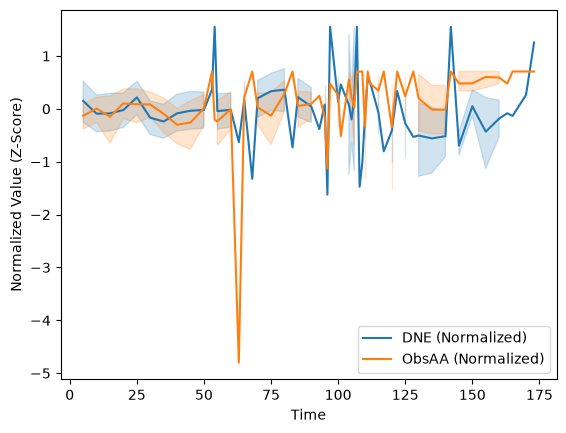

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_grouped, x='Tiempo', y='DNE_norm', label='DNE')
sns.lineplot(data=df_grouped, x='Tiempo', y='ObsAA_norm', label='ObsAA')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

Text(0, 0.5, 'Normalized Value (Z-Score)')

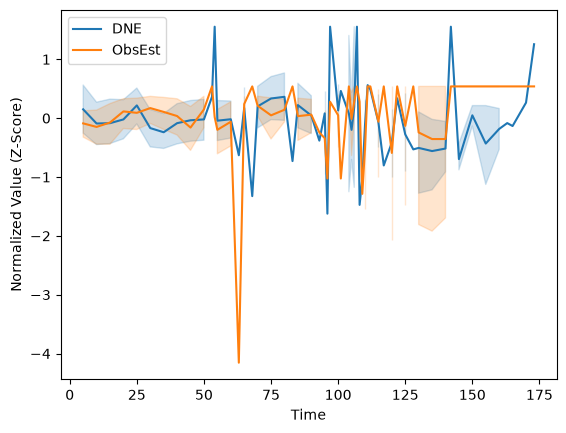

In [39]:
sns.lineplot(data=df_grouped, x='Tiempo', y='DNE_norm', label='DNE')
sns.lineplot(data=df_grouped, x='Tiempo', y='ObsEst_norm', label='ObsEst')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

Text(0, 0.5, 'Normalized Value (Z-Score)')

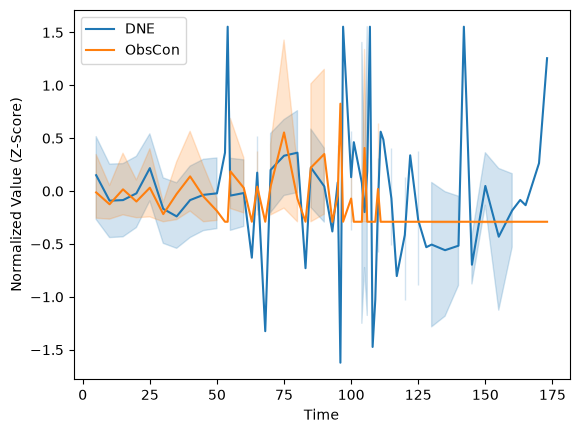

In [40]:
sns.lineplot(data=df_grouped, x='Tiempo', y='DNE_norm', label='DNE')
sns.lineplot(data=df_grouped, x='Tiempo', y='ObsCon_norm', label='ObsCon')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

Text(0, 0.5, 'Normalized Value (Z-Score)')

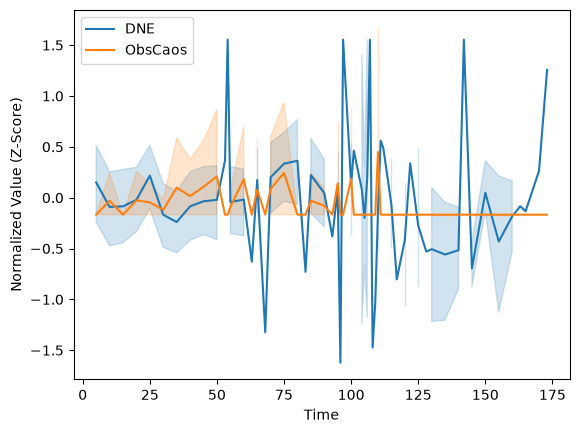

In [41]:
sns.lineplot(data=df_grouped, x='Tiempo', y='DNE_norm', label='DNE')
sns.lineplot(data=df_grouped, x='Tiempo', y='ObsCaos_norm', label='ObsCaos')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

## Lagged

In [44]:
df = pd.read_csv("base.csv", decimal=',')
cols = ['ID', 'Tiempo', 'DNE', 'ObsAA', 'ObsEst', 'ObsCon', 'ObsCaos']
df_subset = df[cols].copy()

# 1. Sanity Check Code (Prints Missing Stats)
missing_summary = df_subset.isna().sum().to_frame(name='Missing Count')
missing_summary['% Missing'] = (missing_summary['Missing Count'] / len(df_subset)) * 100
print(missing_summary)

# 2. Find and drop subjects with 100% missing DNE
missing_dne_by_id = df_subset.groupby('ID')['DNE'].apply(lambda x: x.isna().mean())
bad_ids = missing_dne_by_id[missing_dne_by_id == 1.0].index.tolist()
print(f"Dropping IDs with no DNE data: {bad_ids}")
df_clean = df_subset[~df_subset['ID'].isin(bad_ids)].copy()

# 3. Forward-fill small gaps within each subject's timeline
# This prevents one missing minute from destroying the lag sequence
df_clean = df_clean.sort_values(['ID', 'Tiempo'])
for col in ['DNE', 'ObsAA', 'ObsEst', 'ObsCon', 'ObsCaos']:
    df_clean[col] = df_clean.groupby('ID')[col].ffill()

# 4. Final drop for any remaining NaNs (usually at the very start of a recording)
df_clean = df_clean.dropna().copy()

print(f"Final usable rows: {len(df_clean)}")

         Missing Count  % Missing
ID                   0   0.000000
Tiempo               0   0.000000
DNE                458   9.902703
ObsAA              574  12.410811
ObsEst             693  14.983784
ObsCon             513  11.091892
ObsCaos            436   9.427027
Dropping IDs with no DNE data: [3, 14, 29]
Final usable rows: 4177


In [54]:
df_clean['Time_Block'] = np.ceil(df_clean['Tiempo'] / 5)

df_grouped = df_clean.groupby(['ID', 'Time_Block']).agg({
    'Tiempo': 'max',   # Keeps the end minute (e.g., 5, 10, 15...) as the timestamp
    'DNE': 'median',   # Calculates the median of the 5 DNE values
    'ObsAA': 'first',  # Grabs the repeated 5-min value
    'ObsEst': 'first',
    'ObsCon': 'first',
    'ObsCaos': 'first'
}).reset_index()

df_grouped['DNE_norm'] = zscore(df_grouped['DNE'])
df_grouped['ObsAA_norm'] = zscore(df_grouped['ObsAA'])
df_grouped['ObsEst_norm'] = zscore(df_grouped['ObsEst'])
df_grouped['ObsCon_norm'] = zscore(df_grouped['ObsCon'])
df_grouped['ObsCaos_norm'] = zscore(df_grouped['ObsCaos'])


# FIX: Apply the shift to the aggregated dataframe, not the raw 'df'
# It is also best practice to lag the normalized versions for scale parity
for obs in ['ObsAA', 'ObsEst', 'ObsCon', 'ObsCaos']:
    df_grouped[f'{obs}_norm_lag1'] = df_grouped.groupby('ID')[f'{obs}_norm'].shift(1)

# Drop the first 5-min block for each ID, as it will have a NaN lag by definition
df_lagged = df_grouped.dropna(subset=['ObsAA_norm_lag1']).copy()

df_lagged

,ID,Time_Block,Tiempo,DNE,ObsAA,ObsEst,ObsCon,ObsCaos,DNE_norm,ObsAA_norm,ObsEst_norm,ObsCon_norm,ObsCaos_norm,ObsAA_norm_lag1,ObsEst_norm_lag1,ObsCon_norm_lag1,ObsCaos_norm_lag1
1,1,2.0,10,68.0,3.666667,4.333333,1.0,1.0,-0.064275,-2.394193,-1.428895,-0.300989,-0.15497,-0.833207,-0.682199,-0.300989,-0.15497
2,1,3.0,15,81.0,3.000000,5.333333,1.0,1.0,0.578010,-3.018588,-0.682199,-0.300989,-0.15497,-2.394193,-1.428895,-0.300989,-0.15497
3,1,4.0,20,63.0,3.666667,5.333333,1.0,1.0,-0.311308,-2.394193,-0.682199,-0.300989,-0.15497,-3.018588,-0.682199,-0.300989,-0.15497
4,1,5.0,25,71.0,4.333333,5.666667,1.0,1.0,0.083945,-1.769799,-0.433300,-0.300989,-0.15497,-2.394193,-0.682199,-0.300989,-0.15497
5,1,6.0,30,93.0,5.333333,6.000000,1.0,1.0,1.170888,-0.833207,-0.184402,-0.300989,-0.15497,-1.769799,-0.433300,-0.300989,-0.15497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844,42,18.0,90,42.0,7.000000,7.000000,1.0,1.0,-1.348845,0.727780,0.562294,-0.300989,-0.15497,0.727780,0.562294,-0.300989,-0.15497
845,42,19.0,95,61.0,7.000000,7.000000,1.0,1.0,-0.410121,0.727780,0.562294,-0.300989,-0.15497,0.727780,0.562294,-0.300989,-0.15497
846,42,20.0,100,52.0,7.000000,7.000000,1.0,1.0,-0.854780,0.727780,0.562294,-0.300989,-0.15497,0.727780,0.562294,-0.300989,-0.15497
847,42,21.0,105,51.0,7.000000,7.000000,1.0,1.0,-0.904186,0.727780,0.562294,-0.300989,-0.15497,0.727780,0.562294,-0.300989,-0.15497


Text(0, 0.5, 'Normalized Value (Z-Score)')

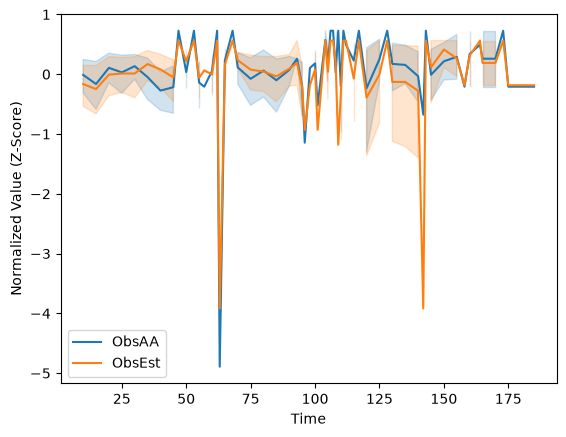

In [62]:
sns.lineplot(data=df_lagged, x='Tiempo', y='ObsAA_norm', label='ObsAA')
sns.lineplot(data=df_lagged, x='Tiempo', y='ObsEst_norm', label='ObsEst')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

Text(0, 0.5, 'Normalized Value (Z-Score)')

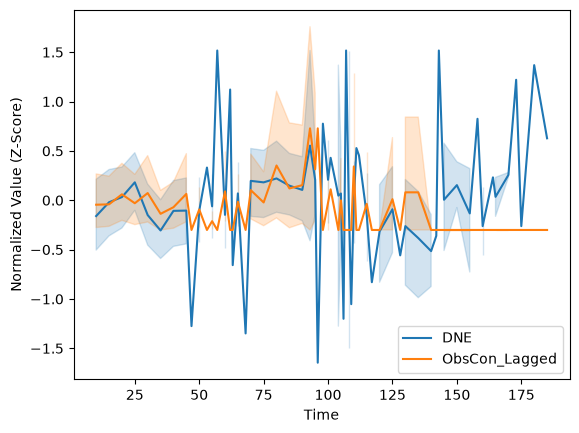

In [61]:
sns.lineplot(data=df_lagged, x='Tiempo', y='DNE_norm', label='DNE')
sns.lineplot(data=df_lagged, x='Tiempo', y='ObsCon_norm_lag1', label='ObsCon_Lagged')
plt.xlabel('Time')
plt.ylabel('Normalized Value (Z-Score)')

In [64]:
import statsmodels.formula.api as smf

# Model 1: Concurrent ObsCon -> DNE
md_concurrent = smf.mixedlm("DNE_norm ~ ObsCon_norm", df_grouped, groups=df_grouped["ID"])
mdf_concurrent = md_concurrent.fit()
print("=== CONCURRENT MODEL ===")
print(mdf_concurrent.summary())

=== CONCURRENT MODEL ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: DNE_norm 
No. Observations: 849     Method:             REML     
No. Groups:       39      Scale:              0.4697   
Min. group size:  10      Log-Likelihood:     -950.2583
Max. group size:  36      Converged:          Yes      
Mean group size:  21.8                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.010    0.122 -0.082 0.934 -0.250  0.230
ObsCon_norm  -0.024    0.027 -0.868 0.385 -0.077  0.030
Group Var     0.561    0.200                           



In [65]:
# Model 2: Lagged ObsCon -> DNE
md_lagged = smf.mixedlm("DNE_norm ~ ObsCon_norm_lag1", df_lagged, groups=df_lagged["ID"])
mdf_lagged = md_lagged.fit()
print("\n=== LAGGED MODEL (Previous 5 mins) ===")
print(mdf_lagged.summary())


=== LAGGED MODEL (Previous 5 mins) ===
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  DNE_norm 
No. Observations:   810      Method:              REML     
No. Groups:         39       Scale:               0.4460   
Min. group size:    9        Log-Likelihood:      -888.9822
Max. group size:    35       Converged:           Yes      
Mean group size:    20.8                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        -0.021    0.123 -0.167 0.868 -0.263  0.221
ObsCon_norm_lag1  0.004    0.027  0.141 0.888 -0.049  0.056
Group Var         0.571    0.209                           



In [72]:
# Model 1: Concurrent ObsCon -> DNE
md_concurrent = smf.mixedlm("DNE_norm ~ ObsCaos_norm", df_grouped, groups=df_grouped["ID"])
mdf_concurrent = md_concurrent.fit()
print("=== CONCURRENT MODEL ===")
print(mdf_concurrent.summary())

=== CONCURRENT MODEL ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: DNE_norm 
No. Observations: 849     Method:             REML     
No. Groups:       39      Scale:              0.4702   
Min. group size:  10      Log-Likelihood:     -950.5959
Max. group size:  36      Converged:          Yes      
Mean group size:  21.8                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.010    0.122 -0.078 0.938 -0.249  0.230
ObsCaos_norm  0.011    0.026  0.446 0.655 -0.039  0.062
Group Var     0.559    0.200                           



In [70]:
# Model 2: Lagged ObsCon -> DNE
md_lagged = smf.mixedlm("DNE_norm ~ ObsCaos_norm_lag1", df_lagged, groups=df_lagged["ID"])
mdf_lagged = md_lagged.fit()
print("\n=== LAGGED MODEL (Previous 5 mins) ===")
print(mdf_lagged.summary())


=== LAGGED MODEL (Previous 5 mins) ===
           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  DNE_norm 
No. Observations:    810      Method:              REML     
No. Groups:          39       Scale:               0.4455   
Min. group size:     9        Log-Likelihood:      -888.6289
Max. group size:     35       Converged:           Yes      
Mean group size:     20.8                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.021    0.124 -0.166 0.868 -0.263  0.222
ObsCaos_norm_lag1  0.023    0.025  0.923 0.356 -0.026  0.072
Group Var          0.573    0.210                           



No se encontraron relaciones predictivas entre las variables observacionales y las mediciones EDA.

## Moments and Events

In [ ]:
df = pd.read_csv("base.csv", decimal=',')

# 2. Select columns and clean the minute-by-minute data
# We keep every valid minute where an event/moment was logged
cols_to_keep = ['ID', 'Tiempo', 'DNE', 'G1', 'X1', "ApoyoAut", 
                "Estruc", "Control",	"Chaos", "SIS_AA",
                "SIS_Est", "SIS_Control", "SIS_Chaos", "NeedSat",
                "NeedFru", "NeedSup", "EstDesm",
                "AutSat", "CompSat", "SatRel", 
                "FrusAut", "FrusComp", "FrusRel",
                "SatLab",	"EmoExha",
                "Cinismo", "Engagement", 
                "Joy",	"Anger", "Anxiety",	"Hope", 
                "Hopelessness", "PerGrow", "RelGrow", 
                "MasGrow", "EducaMat",	"DesBeha", "NoGoal"]

df_events = df.dropna(subset=cols_to_keep).copy()

# 3. Normalize DNE globally so coefficients represent Standard Deviations
df_events['DNE_norm'] = zscore(df_events['DNE'])

print(f"Total usable minute-by-minute rows: {len(df_events)}")

Total usable minute-by-minute rows: 2544



=== LMM: TEACHING MOMENTS (G1) ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: DNE_norm  
No. Observations: 2599    Method:             REML      
No. Groups:       38      Scale:              0.5217    
Min. group size:  5       Log-Likelihood:     -2924.8243
Max. group size:  138     Converged:          Yes       
Mean group size:  68.4                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.012    0.139 -0.087 0.930 -0.286  0.261
C(G1)[T.2.0]   0.161    0.120  1.347 0.178 -0.073  0.396
C(G1)[T.3.0]  -0.083    0.163 -0.509 0.611 -0.402  0.236
C(G1)[T.4.0]  -0.014    0.129 -0.107 0.915 -0.267  0.240
C(G1)[T.5.0]   0.050    0.092  0.541 0.588 -0.130  0.230
C(G1)[T.6.0]  -0.187    0.122 -1.531 0.126 -0.427  0.052
C(G1)[T.7.0]   0.126    0.095  1.327 0.185 -0.060  0.311
C(G1)

/tmp/ipykernel_20852/3882061223.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_events, x='G1', y='DNE_norm', palette='Set2')


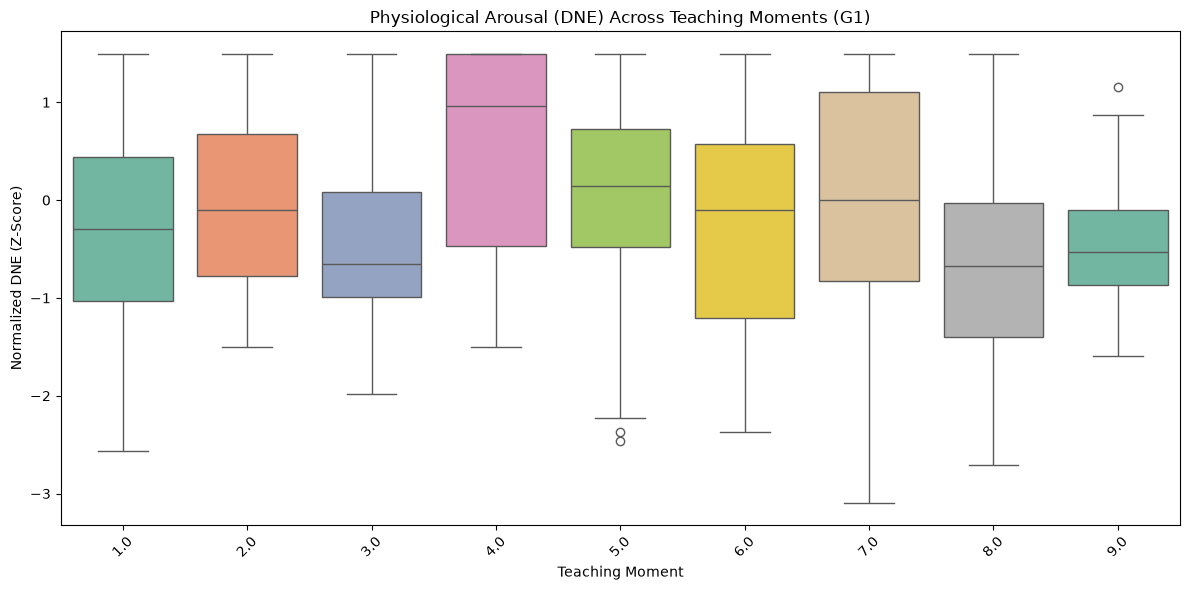

In [90]:
# 4. Model 1: Teaching Moments (G1)
# C(G1) tells the model to treat G1 as a categorical variable
print("\n=== LMM: TEACHING MOMENTS (G1) ===")
try:
    md_g1 = smf.mixedlm("DNE_norm ~ C(G1)", df_events, groups=df_events["ID"])
    mdf_g1 = md_g1.fit()
    print(mdf_g1.summary())
except Exception as e:
    print(f"Error fitting G1 model: {e}")

# Visualization for G1
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_events, x='G1', y='DNE_norm', palette='Set2')
plt.title('Physiological Arousal (DNE) Across Teaching Moments (G1)')
plt.ylabel('Normalized DNE (Z-Score)')
plt.xlabel('Teaching Moment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('g1_boxplot.png', dpi=300)
plt.show()


=== LMM: CRITICAL EVENTS (X1) ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: DNE_norm  
No. Observations: 2599    Method:             REML      
No. Groups:       38      Scale:              0.5235    
Min. group size:  5       Log-Likelihood:     -2929.4867
Max. group size:  138     Converged:          Yes       
Mean group size:  68.4                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.036    0.120 -0.298 0.766 -0.272  0.200
C(X1)[T.2.0]  -0.559    0.246 -2.271 0.023 -1.042 -0.076
C(X1)[T.3.0]   0.113    0.084  1.343 0.179 -0.052  0.278
C(X1)[T.4.0]   0.066    0.240  0.276 0.783 -0.405  0.537
C(X1)[T.5.0]   0.090    0.086  1.036 0.300 -0.080  0.259
C(X1)[T.6.0]  -0.054    0.055 -0.994 0.320 -0.162  0.053
C(X1)[T.7.0]  -0.529    0.336 -1.573 0.116 -1.187  0.130
C(X1)[

/tmp/ipykernel_20852/1334364752.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_events, x='X1', y='DNE_norm', palette='Set1')


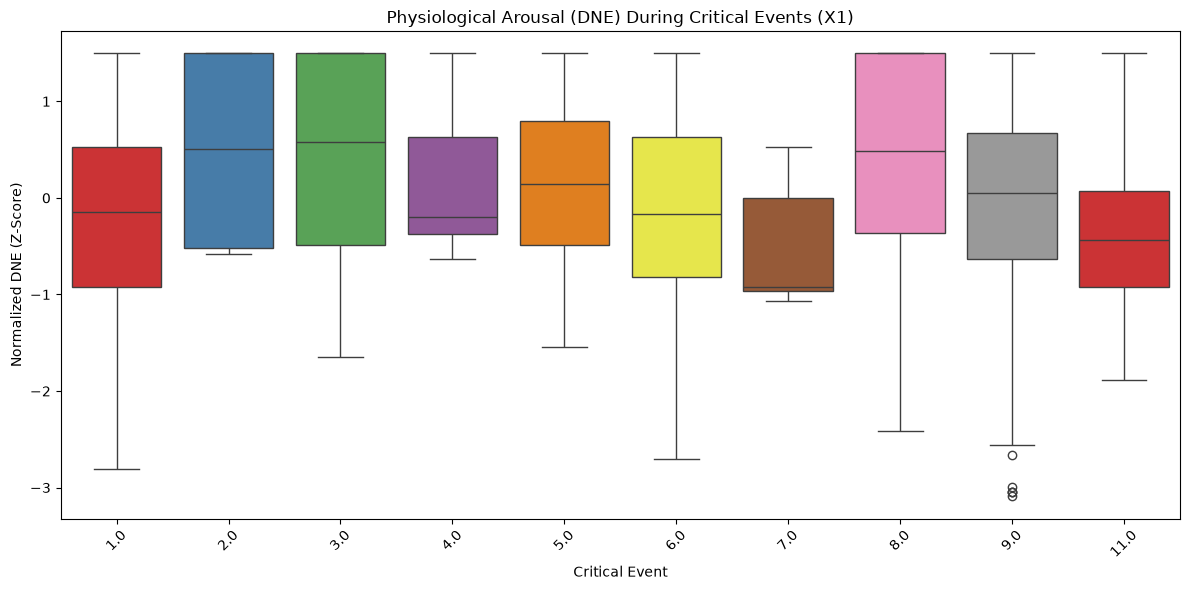

In [79]:
# 5. Model 2: Critical Events (X1)
print("\n=== LMM: CRITICAL EVENTS (X1) ===")
try:
    md_x1 = smf.mixedlm("DNE_norm ~ C(X1)", df_events, groups=df_events["ID"])
    mdf_x1 = md_x1.fit()
    print(mdf_x1.summary())
except Exception as e:
    print(f"Error fitting X1 model: {e}")

# Visualization for X1
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_events, x='X1', y='DNE_norm', palette='Set1')
plt.title('Physiological Arousal (DNE) During Critical Events (X1)')
plt.ylabel('Normalized DNE (Z-Score)')
plt.xlabel('Critical Event')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('x1_boxplot.png', dpi=300)
plt.show()

Se encontró que los eventos de la clase (X1) y momentos de enseñanza (G1) pueden predecir la señal EDA.

### Self-report

In [ ]:
level2_cols = [
                "ID", 
                "ApoyoAut", "Estruc", "Control",	"Chaos", "SIS_AA",
                "SIS_Est", "SIS_Control", "SIS_Chaos", "NeedSat",
                "NeedFru", "NeedSup", "EstDesm",
                "AutSat", "CompSat", "SatRel", 
                "FrusAut", "FrusComp", "FrusRel",
                "SatLab",	"EmoExha",
                "Cinismo", "Engagement", 
                "Joy",	"Anger", "Anxiety",	"Hope", 
                "Hopelessness", "PerGrow", "RelGrow", 
                "MasGrow", "EducaMat",	"DesBeha", "NoGoal"]

available_cols = [col for col in level2_cols if col in df.columns]
df_l2 = df[available_cols].drop_duplicates(subset=['ID']).copy()
df_l2

,ID,ApoyoAut,Estruc,Control,Chaos,SIS_AA,SIS_Est,SIS_Control,SIS_Chaos,NeedSat,...,Anger,Anxiety,Hope,Hopelessness,PerGrow,RelGrow,MasGrow,EducaMat,DesBeha,NoGoal
0,1,5.83,6.4,3.50,2.2,4.75,5.88,2.00,3.13,5.58,...,3.50,3.00,6.25,1.75,6.00,5.00,6.75,3.50,4.00,3.67
101,2,5.67,6.0,1.50,2.4,4.44,5.12,1.56,2.07,6.25,...,2.50,4.50,6.00,2.50,6.00,5.50,6.50,3.00,2.00,2.00
210,3,6.17,6.0,1.25,1.6,4.69,5.18,1.63,1.60,6.50,...,1.00,1.00,7.00,1.00,6.50,6.50,6.75,5.00,3.25,1.00
391,4,6.00,6.0,1.00,3.0,5.50,6.53,1.19,1.73,6.25,...,1.00,2.50,7.00,1.00,6.50,6.75,7.00,4.50,2.25,2.67
511,5,5.17,5.8,4.50,1.6,4.19,4.59,2.69,1.53,6.08,...,2.00,1.75,6.25,1.00,6.25,5.00,6.50,3.25,3.00,1.33
616,6,7.00,7.0,1.50,1.0,6.06,6.29,1.38,2.00,7.00,...,1.00,1.00,7.00,1.00,7.00,7.00,7.00,6.75,4.75,1.00
801,7,6.17,6.0,1.00,1.2,4.31,6.12,1.25,2.20,6.83,...,1.00,1.75,6.75,1.75,6.75,6.75,7.00,2.00,2.50,1.00
959,8,5.83,6.2,3.75,2.0,4.44,5.65,1.44,1.80,6.92,...,1.00,2.50,7.00,1.00,7.00,7.00,7.00,4.75,3.00,3.00
1101,9,6.17,6.0,3.00,2.2,5.19,5.59,2.50,1.80,6.83,...,1.00,3.75,6.75,1.00,6.25,5.75,6.25,3.25,2.50,1.00
1236,10,5.67,5.8,1.75,1.2,5.06,5.59,1.50,2.33,6.00,...,1.00,1.75,5.75,1.00,6.50,6.00,6.50,3.75,3.25,2.33


In [ ]:
corr_matrix = df_l2.drop(columns=['ID']).corr().round(2)
corr_matrix

,ApoyoAut,Estruc,Control,Chaos,SIS_AA,SIS_Est,SIS_Control,SIS_Chaos,NeedSat,NeedFru,...,Anger,Anxiety,Hope,Hopelessness,PerGrow,RelGrow,MasGrow,EducaMat,DesBeha,NoGoal
ApoyoAut,1.00,0.76,-0.25,-0.11,0.82,0.66,-0.07,0.17,0.63,-0.35,...,-0.29,-0.19,0.63,-0.33,0.65,0.58,0.72,0.26,0.15,-0.43
Estruc,0.76,1.00,-0.17,-0.14,0.66,0.67,-0.10,0.09,0.72,-0.43,...,-0.27,-0.41,0.68,-0.40,0.65,0.45,0.70,0.23,0.13,-0.36
Control,-0.25,-0.17,1.00,0.14,-0.24,-0.21,0.49,0.01,-0.26,0.34,...,0.34,0.19,-0.18,0.01,-0.07,-0.28,0.01,0.25,0.33,0.08
Chaos,-0.11,-0.14,0.14,1.00,-0.04,-0.02,0.27,0.24,-0.14,0.30,...,0.19,0.24,0.15,0.08,-0.19,-0.18,-0.07,-0.06,-0.10,0.31
SIS_AA,0.82,0.66,-0.24,-0.04,1.00,0.72,-0.03,0.02,0.53,-0.40,...,-0.31,-0.23,0.57,-0.33,0.53,0.54,0.59,0.34,0.23,-0.29
SIS_Est,0.66,0.67,-0.21,-0.02,0.72,1.00,-0.03,0.02,0.62,-0.39,...,-0.33,-0.16,0.57,-0.35,0.48,0.43,0.62,0.25,0.17,-0.19
SIS_Control,-0.07,-0.10,0.49,0.27,-0.03,-0.03,1.00,0.38,-0.12,0.42,...,0.29,0.25,-0.01,0.04,-0.04,-0.12,0.06,0.29,0.34,-0.02
SIS_Chaos,0.17,0.09,0.01,0.24,0.02,0.02,0.38,1.00,-0.06,0.43,...,0.27,-0.01,0.17,0.03,0.09,-0.03,0.04,0.16,0.05,0.07
NeedSat,0.63,0.72,-0.26,-0.14,0.53,0.62,-0.12,-0.06,1.00,-0.58,...,-0.48,-0.45,0.76,-0.49,0.45,0.39,0.54,0.08,0.05,-0.33
NeedFru,-0.35,-0.43,0.34,0.30,-0.40,-0.39,0.42,0.43,-0.58,1.00,...,0.53,0.59,-0.42,0.56,-0.18,-0.34,-0.23,0.09,0.02,0.21


In [136]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

# 1. Modelo Base (Solo predictores de Nivel 1 limpios)
m_base = smf.mixedlm("DNE_norm ~ C(X1)", df_events, groups=df_events["ID"]).fit(reml=False)

# 2. Probar Bloque 1: Estilos Motivacionales del Docente (Globales)
m_block1 = smf.mixedlm("DNE_norm ~ C(X1) + NeedSup + EstDesm", df_events, groups=df_events["ID"]).fit(reml=False)
#m_block1 = smf.mixedlm("DNE_norm ~ C(X1) + SIS_AA + SIS_Est + SIS_Control + SIS_Chaos", df_events, groups=df_events["ID"]).fit(reml=False)
#m_block1 = smf.mixedlm("DNE_norm ~ C(X1) + ApoyoAut + Estruc + Control + Chaos", df_events, groups=df_events["ID"]).fit(reml=False)

# 3. Probar Bloque 2: Frustración y Satisfacción de Necesidades (Globales)
#m_block2 = smf.mixedlm("DNE_norm ~ C(X1) + NeedSat + NeedFru", df_events, groups=df_events["ID"]).fit(reml=False)
m_block2 = smf.mixedlm("DNE_norm ~ C(X1) + AutSat + CompSat + SatRel + FrusAut + FrusComp + FrusRel", df_events, groups=df_events["ID"]).fit(reml=False)

# 4. Probar Bloque 3: Crecimiento y Metas (Variables seleccionadas sin multicolinealidad)
m_block3 = smf.mixedlm("DNE_norm ~ C(X1) + MasGrow + EducaMat + NoGoal", df_events, groups=df_events["ID"]).fit(reml=False)

# Emociones
m_block4 = smf.mixedlm("DNE_norm ~ C(X1) + Hope + Anger + Anxiety + Hopelessness", df_events, groups=df_events["ID"]).fit(reml=False)
#m_block4 = smf.mixedlm("DNE_norm ~ C(X1) + EmoPos + EmoNeg", df_events, groups=df_events["ID"]).fit(reml=False)


def test_block_significance(model_base, model_block, block_name):
    """Calcula la prueba de verosimilitud (LRT) entre el modelo base y el bloque."""
    lr_stat = 2 * (model_block.llf - model_base.llf)
    df_diff = len(model_block.params) - len(model_base.params)
    p_val = chi2.sf(lr_stat, df_diff)
    print(f"--- {block_name} ---")
    print(f"Estadístico LRT: {lr_stat:.3f} | Grados de Libertad: {df_diff} | p-valor: {p_val:.4f}")
    if p_val < 0.05:
        print("-> El bloque MEJORA significativamente el ajuste del modelo.\n")
    else:
        print("-> El bloque NO aporta explicatividad significativa.\n")

# Ejecutar pruebas LRT
test_block_significance(m_base, m_block1, "Bloque 1: Estilos Docentes")
test_block_significance(m_base, m_block2, "Bloque 2: Necesidades Psicológicas")
test_block_significance(m_base, m_block3, "Bloque 3: Crecimiento y Metas")
test_block_significance(m_base, m_block4, "Bloque 4: Emociones")


--- Bloque 1: Estilos Docentes ---
Estadístico LRT: 3.493 | Grados de Libertad: 2 | p-valor: 0.1744
-> El bloque NO aporta explicatividad significativa.

--- Bloque 2: Necesidades Psicológicas ---
Estadístico LRT: 8.635 | Grados de Libertad: 6 | p-valor: 0.1952
-> El bloque NO aporta explicatividad significativa.

--- Bloque 3: Crecimiento y Metas ---
Estadístico LRT: 5.713 | Grados de Libertad: 3 | p-valor: 0.1264
-> El bloque NO aporta explicatividad significativa.

--- Bloque 4: Emociones ---
Estadístico LRT: 0.742 | Grados de Libertad: 4 | p-valor: 0.9461
-> El bloque NO aporta explicatividad significativa.



No se encontraron efectos principales de las variables de rasgo (auto-reporte) sobre la señal EDA.

Tiene sentido pues la señal DRE que arroja Nuanic está calibrada y estandarizada. De modo que los niveles basales ya están corregidos y no se podrían asociar a variables psicológicas de rasgo.

### Interactions

In [146]:
import pandas as pd

# 1. Agregar datos a Nivel 2 (un promedio de DNE por ID y una fila por cuestionario)
l2_summary = df_events.groupby('ID').agg({
    'DNE_norm': 'mean',
    'AutSat': 'first',
    'CompSat': 'first',
    'SatRel' : 'first',
    'FrusAut': 'first',
    'FrusComp': 'first',
    'FrusRel': 'first',
    'MasGrow': 'first',
    'EducaMat': 'first',
    "NoGoal": 'first',
    'EstDesm': 'first',
    'NeedSup': 'first',
}).dropna()

# 2. Correlación bivariada directa con la media de DNE del estudiante
corrs_with_dne = l2_summary.corr()['DNE_norm'].drop('DNE_norm').sort_values(ascending=False)

print("--- Correlación bivariada Nivel 2 con la media de DNE del estudiante ---")
print(corrs_with_dne.round(3))

--- Correlación bivariada Nivel 2 con la media de DNE del estudiante ---
FrusAut     0.207
EstDesm     0.166
NoGoal      0.130
FrusRel     0.078
EducaMat    0.037
SatRel      0.032
AutSat     -0.066
FrusComp   -0.099
CompSat    -0.184
NeedSup    -0.232
MasGrow    -0.340
Name: DNE_norm, dtype: float64


In [157]:
# Modelo Omnibus: Todas las categorías principales de X1 interactúan con MasGrow
m_int_all = smf.mixedlm("DNE_norm ~ C(X1) * MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)
m_add_all = smf.mixedlm("DNE_norm ~ C(X1) + MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)

# Prueba LRT
lr_stat = 2 * (m_int_all.llf - m_add_all.llf)
df_diff = len(m_int_all.params) - len(m_add_all.params)
print(f"LRT Omnibus (X1 * MasGrow): Stat = {lr_stat:.3f}, df = {df_diff}, p = {chi2.sf(lr_stat, df_diff):.4f}")

LRT Omnibus (X1 * MasGrow): Stat = inf, df = 9, p = 0.0000


/home/renato/.virtualenvs/nuanic/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_20852/1461036620.py:2: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  m_int_all = smf.mixedlm("DNE_norm ~ C(X1) * MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)
/home/renato/.virtualenvs/nuanic/lib/python3.12/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/renato/.virtualenvs/nuanic/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2429: SingularMatrixWarning: The random effects covariance matrix is singular.
  scale = self.get_scale(fe_params, cov_re_unscaled, vcomp_unscaled)
/tmp/ipykernel_20852/1461036620.py:2: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  m_

In [167]:
# Crear indicador dummy para X1 = 8
df_events['X1_8'] = (df_events['X1'] == 8.0).astype(float)
df_events['X1_2'] = (df_events['X1'] == 2.0).astype(float)

# Modelo con todas las categorías como efectos principales + interacción focal X1_8 * MasGrow
m_focal = smf.mixedlm("DNE_norm ~ C(X1) + MasGrow + X1_2:MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)
m_main  = smf.mixedlm("DNE_norm ~ C(X1) + MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)

lr_stat = 2 * (m_focal.llf - m_main.llf)
print(f"LRT Focal (X1_2 * MasGrow): Stat = {lr_stat:.3f}, df = 1, p = {chi2.sf(lr_stat, 1):.4f}")

LRT Focal (X1_2 * MasGrow): Stat = 11.693, df = 1, p = 0.0006


In [168]:
# Modelo con todas las categorías como efectos principales + interacción focal X1_8 * MasGrow
m_focal = smf.mixedlm("DNE_norm ~ C(X1) + NeedSup + X1_2:NeedSup", df_events, groups=df_events["ID"]).fit(reml=False)
m_main  = smf.mixedlm("DNE_norm ~ C(X1) + NeedSup", df_events, groups=df_events["ID"]).fit(reml=False)

lr_stat = 2 * (m_focal.llf - m_main.llf)
print(f"LRT Focal (X1_2 * NeedSup): Stat = {lr_stat:.3f}, df = 1, p = {chi2.sf(lr_stat, 1):.4f}")

LRT Focal (X1_2 * NeedSup): Stat = 11.828, df = 1, p = 0.0006


In [170]:
# Modelo con todas las categorías como efectos principales + interacción focal X1_8 * MasGrow
m_focal = smf.mixedlm("DNE_norm ~ C(X1) + FrusAut + X1_2:FrusAut", df_events, groups=df_events["ID"]).fit(reml=False)
m_main  = smf.mixedlm("DNE_norm ~ C(X1) + FrusAut", df_events, groups=df_events["ID"]).fit(reml=False)

lr_stat = 2 * (m_focal.llf - m_main.llf)
print(f"LRT Focal (X1_2 * FrusAut): Stat = {lr_stat:.3f}, df = 1, p = {chi2.sf(lr_stat, 1):.4f}")

LRT Focal (X1_2 * FrusAut): Stat = -1.599, df = 1, p = 1.0000


/home/renato/.virtualenvs/nuanic/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_20852/1145326251.py:2: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  m_focal = smf.mixedlm("DNE_norm ~ C(X1) + FrusAut + X1_2:FrusAut", df_events, groups=df_events["ID"]).fit(reml=False)


In [171]:
# Recrear los modelos focales ganadores
df_events['X1_2'] = (df_events['X1'] == 2.0).astype(float)

m_focal_masgrow = smf.mixedlm("DNE_norm ~ C(X1) + MasGrow + X1_2:MasGrow", df_events, groups=df_events["ID"]).fit(reml=False)
m_focal_needsup = smf.mixedlm("DNE_norm ~ C(X1) + NeedSup + X1_2:NeedSup", df_events, groups=df_events["ID"]).fit(reml=False)

# Imprimir las tablas de coeficientes
print(m_focal_masgrow.summary().tables[1].loc[['C(X1)[T.2.0]', 'MasGrow', 'X1_2:MasGrow']])
print("\n--------------------------------------------------\n")
print(m_focal_needsup.summary().tables[1].loc[['C(X1)[T.2.0]', 'NeedSup', 'X1_2:NeedSup']])

               Coef. Std.Err.       z  P>|z|  [0.025  0.975]
C(X1)[T.2.0]  14.013    4.249   3.298  0.001   5.685  22.340
MasGrow       -0.367    0.161  -2.272  0.023  -0.683  -0.050
X1_2:MasGrow  -2.194    0.641  -3.424  0.001  -3.450  -0.938

--------------------------------------------------

                Coef. Std.Err.       z  P>|z|   [0.025   0.975]
C(X1)[T.2.0]  318.607   92.681   3.438  0.001  136.955  500.259
NeedSup        -0.261    0.166  -1.574  0.115   -0.586    0.064
X1_2:NeedSup  -55.164   16.021  -3.443  0.001  -86.566  -23.763


Se encuentra relación de moderación entre variables de rasgo (auto-reporte) y eventos de clase (X1) para predecir la señal EDA.

### TO-DO

- Confirmar hallazgos sobre la moderación.
- Verificar una forma más elegante para explorar la variable X1. Ahora forcé a escoger los valores de X1=2, o X1=8, pues me salieron significativos más arriba.
- Diseñar visualización para ilustrar la relación de moderación en la señal EDA.
- ¿Hay otras alternativas de modelado? 